# 06 - Risk Analizi ve Açıklanabilir Yapay Zeka (SHAP)

Bu notebook'ta:
1. Tahmin edilen değerler üzerinden **Normal / Yoğun / Kritik** risk sınıflandırması yapılmaktadır.
2. **Feature Importance** ve **SHAP** analizi ile model kararları yorumlanabilir hale getirilmektedir.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
import shap
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score, classification_report
print('SHAP version:', shap.__version__)

SHAP version: 0.52.0


## Veri + Feature Engineering

In [4]:
ddf = pd.read_csv('../data/raw/request_level_data.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

for lag in [1, 2, 3]:
    df[f'response_time_lag_{lag}'] = df['response_time_ms'].shift(lag)

df['response_time_roll_mean_5']  = df['response_time_ms'].shift(1).rolling(5).mean()
df['response_time_roll_mean_10'] = df['response_time_ms'].shift(1).rolling(10).mean()
df['response_time_roll_std_5']   = df['response_time_ms'].shift(1).rolling(5).std()

le = joblib.load('../models/label_encoder.pkl')
df['endpoint_encoded'] = le.transform(df['endpoint_name'])

df = df.dropna().reset_index(drop=True)
print(f'Veri boyutu: {df.shape}')

Veri boyutu: (29199, 21)


In [5]:
features = [
    'payload_size', 'active_requests', 'rps_10s', 'requests_last_60s',
    'response_time_lag_1', 'response_time_lag_2', 'response_time_lag_3',
    'response_time_roll_mean_5', 'response_time_roll_mean_10',
    'response_time_roll_std_5', 'endpoint_encoded'
]
target = 'response_time_ms'
WINDOW_SIZE = 10

def create_window(df, features, target, window_size):
    X, y = [], []
    for i in range(len(df) - window_size):
        X.append(df[features].iloc[i:i+window_size].values)
        y.append(df[target].iloc[i+window_size])
    return np.array(X), np.array(y)

X, y = create_window(df, features, target, WINDOW_SIZE)
X_flat = X.reshape(X.shape[0], -1)

split = int(len(X_flat) * 0.8)
X_train, X_test = X_flat[:split], X_flat[split:]
y_train, y_test = y[:split], y[split:]
print(f'Test: {X_test.shape}')

Test: (5838, 110)


## Enhanced RF Yükleme

In [6]:
rf = joblib.load('../models/random_forest_enhanced.pkl')
y_pred_rf = rf.predict(X_test)
print(f'MAE: {mean_absolute_error(y_test, y_pred_rf):.2f}')
print(f'R2:  {r2_score(y_test, y_pred_rf):.4f}')

MAE: 88.14
R2:  0.4113


## Risk Sınıflandırması

| Sınıf | Eşik |
|-------|------|
| Normal | < 500 ms |
| Yoğun | 500–1000 ms |
| Kritik | > 1000 ms |

In [7]:
def classify_risk(ms):
    if ms < 500: return 'Normal'
    elif ms < 1000: return 'Yoğun'
    return 'Kritik'

risk_df = pd.DataFrame({'y_true': y_test, 'y_pred_rf': y_pred_rf})
risk_df['risk_true'] = risk_df['y_true'].apply(classify_risk)
risk_df['risk_pred'] = risk_df['y_pred_rf'].apply(classify_risk)

print('Gerçek:\n', risk_df['risk_true'].value_counts())
print('\nTahmin:\n', risk_df['risk_pred'].value_counts())

Gerçek:
 risk_true
Normal    5066
Yoğun      730
Kritik      42
Name: count, dtype: int64

Tahmin:
 risk_pred
Normal    5477
Yoğun      358
Kritik       3
Name: count, dtype: int64


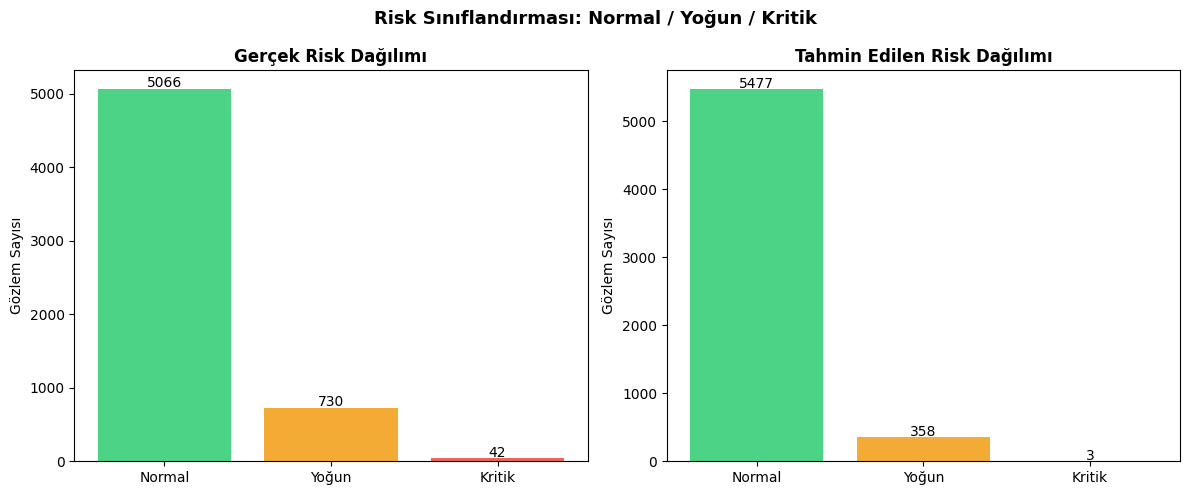

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
risk_colors = {'Normal': '#2ecc71', 'Yoğun': '#f39c12', 'Kritik': '#e74c3c'}
risk_order  = ['Normal', 'Yoğun', 'Kritik']

for ax, col, title in zip(axes, ['risk_true', 'risk_pred'],
                          ['Gerçek Risk Dağılımı', 'Tahmin Edilen Risk Dağılımı']):
    counts = risk_df[col].value_counts().reindex(risk_order, fill_value=0)
    bars = ax.bar(counts.index, counts.values,
                  color=[risk_colors[r] for r in counts.index], alpha=0.85)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Gözlem Sayısı')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                str(val), ha='center', fontsize=10)

plt.suptitle('Risk Sınıflandırması: Normal / Yoğun / Kritik', fontsize=13, fontweight='bold')
plt.tight_layout()
os.makedirs('../outputs', exist_ok=True)
plt.savefig('../outputs/risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
print(classification_report(risk_df['risk_true'], risk_df['risk_pred']))

              precision    recall  f1-score   support

      Kritik       0.67      0.05      0.09        42
      Normal       0.90      0.98      0.94      5066
       Yoğun       0.63      0.31      0.41       730

    accuracy                           0.89      5838
   macro avg       0.73      0.44      0.48      5838
weighted avg       0.87      0.89      0.87      5838



## SHAP Analizi

In [10]:
feature_names_flat = []
for t in range(WINDOW_SIZE):
    for f in features:
        feature_names_flat.append(f'{f}_t-{WINDOW_SIZE - t}')

np.random.seed(42)
explain_idx = np.random.choice(len(X_test), size=500, replace=False)
X_explain   = X_test[explain_idx]

print('SHAP hesaplanıyor... (1-2 dk)')
explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_explain)
print(f'Tamamlandı. Shape: {shap_values.shape}')

SHAP hesaplanıyor... (1-2 dk)
Tamamlandı. Shape: (500, 110)


In [11]:
shap_grouped = np.zeros((shap_values.shape[0], len(features)))
for fi, feat in enumerate(features):
    indices = [j for j, name in enumerate(feature_names_flat) if name.startswith(feat + '_t-')]
    shap_grouped[:, fi] = shap_values[:, indices].sum(axis=1)

X_explain_df = pd.DataFrame(X_explain, columns=feature_names_flat)
X_explain_grouped = pd.DataFrame({
    feat: X_explain_df[[c for c in feature_names_flat if c.startswith(feat + '_t-')]].mean(axis=1)
    for feat in features
})
print('Grouped SHAP shape:', shap_grouped.shape)

Grouped SHAP shape: (500, 11)


C:\Users\bahar\AppData\Local\Temp\ipykernel_568\3298503202.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_grouped, X_explain_grouped, feature_names=features, show=False)


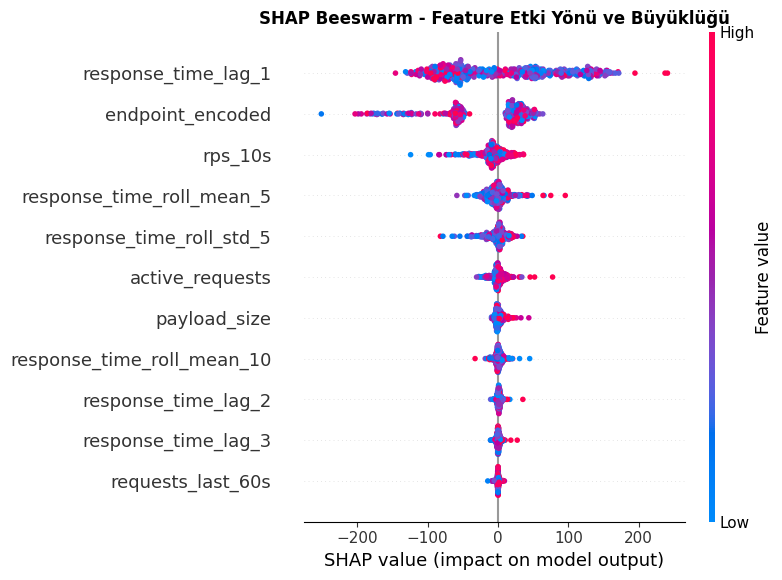

In [12]:
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_grouped, X_explain_grouped, feature_names=features, show=False)
plt.title('SHAP Beeswarm - Feature Etki Yönü ve Büyüklüğü', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\bahar\AppData\Local\Temp\ipykernel_568\4197625871.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_grouped, X_explain_grouped, feature_names=features,


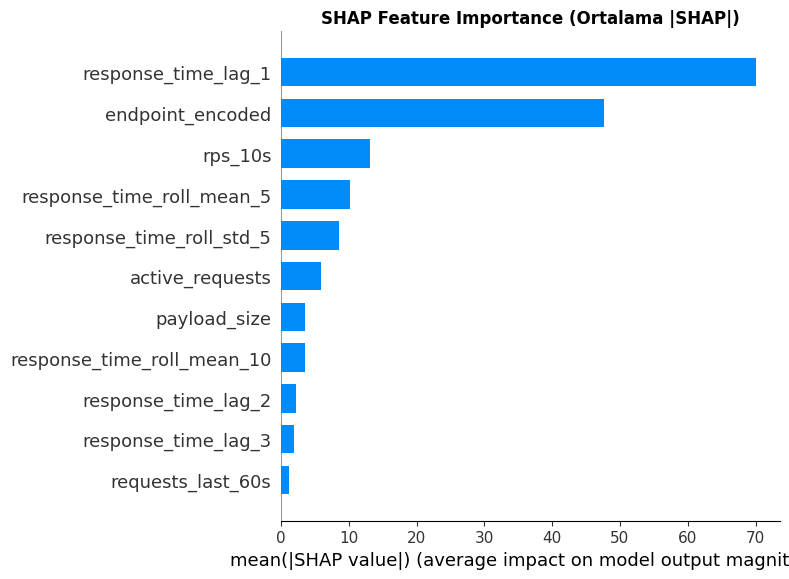

In [13]:
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_grouped, X_explain_grouped, feature_names=features,
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Ortalama |SHAP|)', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

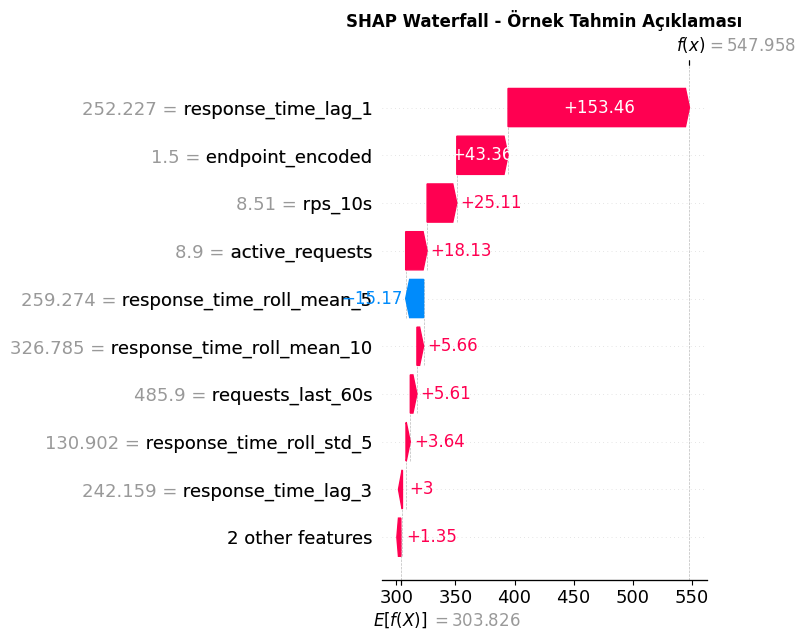

Gerçek: 651.8 ms  |  Tahmin: 548.0 ms


In [14]:
expected_value = explainer.expected_value
if isinstance(expected_value, np.ndarray):
    expected_value = float(expected_value[0])

shap.waterfall_plot(
    shap.Explanation(
        values=shap_grouped[0],
        base_values=expected_value,
        data=X_explain_grouped.iloc[0].values,
        feature_names=features
    ), show=False
)
plt.title('SHAP Waterfall - Örnek Tahmin Açıklaması', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Gerçek: {y_test[explain_idx[0]]:.1f} ms  |  Tahmin: {y_pred_rf[explain_idx[0]]:.1f} ms')

## Kaydetme

In [15]:
os.makedirs('../data', exist_ok=True)
risk_df.to_csv('../data/risk_results.csv', index=False)

shap_summary = pd.DataFrame({
    'feature': features,
    'mean_abs_shap': np.abs(shap_grouped).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)
shap_summary.to_csv('../data/shap_summary.csv', index=False)

print('Kaydedildi.')
print(shap_summary.to_string(index=False))

Kaydedildi.
                   feature  mean_abs_shap
       response_time_lag_1      70.105912
          endpoint_encoded      47.665138
                   rps_10s      13.138907
 response_time_roll_mean_5      10.114953
  response_time_roll_std_5       8.525916
           active_requests       5.898479
              payload_size       3.516961
response_time_roll_mean_10       3.490333
       response_time_lag_2       2.176536
       response_time_lag_3       1.851516
         requests_last_60s       1.118599
